In [28]:
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [29]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ.get("GOOGLE_API_KEY")
os.environ.get("TAVILY_API_KEY")


'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'

In [30]:
from typing import Annotated
from typing_extensions import TypedDict
class State(TypedDict):
    messages : Annotated[list,add_messages]

In [31]:
from langchain.chat_models import init_chat_model
model = init_chat_model("google_genai:gemini-2.5-flash")

In [32]:
def chatbot(state):
    return {"messages" : [model.invoke(state["messages"])]}

In [33]:
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot",chatbot)
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)
graph = graph_builder.compile()

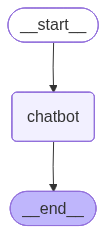

In [34]:
graph

In [35]:
response = graph.invoke({"messages" : "Hi"})
print(response["messages"][-1])

content='Hi there! How can I help you today?' additional_kwargs={} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019ebb46-d32a-73b3-b603-f83c36dafb5f-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 2, 'output_tokens': 37, 'total_tokens': 39, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 27}}


In [56]:
from langchain_tavily import TavilySearch
from langchain.tools import tool
tool = TavilySearch(max_results=2)

In [37]:
def multiply(a : int,b : int)->int:
    """Takes the two integers and returns the multiplication

    Args:
        a : first Integer
        b : second Integer
    
    Output:
        ans : a * b : int

    """
    return a * b


In [38]:
tools = [tool,multiply]
llm_with_tools = model.bind_tools(tools)

In [39]:
def tool_calling_llm(state:State):
    return {"messages" : [llm_with_tools.invoke(state["messages"])]}

In [40]:
from langgraph.prebuilt import ToolNode,tools_condition
graph_builder = StateGraph(State)
graph_builder.add_node("tool_calling_llm",tool_calling_llm)
graph_builder.add_node("tools",ToolNode(tools))
graph_builder.add_edge(START,"tool_calling_llm")
graph_builder.add_conditional_edges("tool_calling_llm",tools_condition)

graph_builder.add_edge("tools",END)
graph = graph_builder.compile()

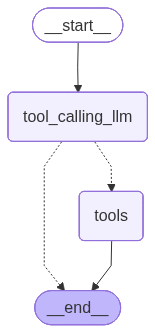

In [41]:
graph

In [42]:
response = graph.invoke({"messages":"What is the climate like in India?"})
response["messages"][-1].content

'{"query": "climate in India", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://bluegreenatlas.com/climate/india_climate.html", "title": "The Climate of India - Blue Green Atlas", "content": "## What is the climate of India like? It stretches from 8° to 33°N and includes vast plains like the Ganges valley and high mountains like the Himalayas - the highest in the world. The climate of India is dominated by the major wind system known as the Asian monsoon. Thus, the monsoon helps divide the year into four seasons: the relatively dry, cool winter from December through February; the dry, hot summer from March through May; the southwest monsoon from June through September when the predominating southwest maritime winds bring rains to most of the country; and the northeast, or retreating, monsoon of October and November. From June to October, the country is influenced by the wet, rainy southwest monsoon. India can be divided into seven climatic regions

In [43]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the climate like in India?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (d4315be2-ef8b-41f4-a7a7-20a4a52a270c)
 Call ID: d4315be2-ef8b-41f4-a7a7-20a4a52a270c
  Args:
    search_depth: basic
    query: climate in India
================================= Tool Message =================================
Name: tavily_search

{"query": "climate in India", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://bluegreenatlas.com/climate/india_climate.html", "title": "The Climate of India - Blue Green Atlas", "content": "## What is the climate of India like? It stretches from 8° to 33°N and includes vast plains like the Ganges valley and high mountains like the Himalayas - the highest in the world. The climate of India is dominated by the major wind system known as the Asian monsoon. Thus, the monsoon helps divi

In [44]:
response = graph.invoke({"messages" : "What is weather like in India and then give me multiplication of 2 and 10"})
response["messages"][-1].content

'{"query": "weather in India", "follow_up_questions": null, "answer": null, "images": [], "results": [{"title": "Weather in India", "url": "https://www.weatherapi.com/", "content": "{\'location\': {\'name\': \'New Delhi\', \'region\': \'Delhi\', \'country\': \'India\', \'lat\': 28.6, \'lon\': 77.2, \'tz_id\': \'Asia/Kolkata\', \'localtime_epoch\': 1781258316, \'localtime\': \'2026-06-12 15:28\'}, \'current\': {\'last_updated_epoch\': 1781257500, \'last_updated\': \'2026-06-12 15:15\', \'temp_c\': 33.1, \'temp_f\': 91.6, \'is_day\': 1, \'condition\': {\'text\': \'Partly cloudy\', \'icon\': \'//cdn.weatherapi.com/weather/64x64/day/116.png\', \'code\': 1003}, \'wind_mph\': 6.0, \'wind_kph\': 9.7, \'wind_degree\': 91, \'wind_dir\': \'E\', \'pressure_mb\': 1005.0, \'pressure_in\': 29.68, \'precip_mm\': 0.0, \'precip_in\': 0.0, \'humidity\': 47, \'cloud\': 50, \'feelslike_c\': 31.0, \'feelslike_f\': 87.7, \'windchill_c\': 42.8, \'windchill_f\': 109.1, \'heatindex_c\': 44.3, \'heatindex_f\': 

In [45]:
for m in response["messages"]:
    print(m.content)

What is weather like in India and then give me multiplication of 2 and 10

{"query": "weather in India", "follow_up_questions": null, "answer": null, "images": [], "results": [{"title": "Weather in India", "url": "https://www.weatherapi.com/", "content": "{'location': {'name': 'New Delhi', 'region': 'Delhi', 'country': 'India', 'lat': 28.6, 'lon': 77.2, 'tz_id': 'Asia/Kolkata', 'localtime_epoch': 1781258316, 'localtime': '2026-06-12 15:28'}, 'current': {'last_updated_epoch': 1781257500, 'last_updated': '2026-06-12 15:15', 'temp_c': 33.1, 'temp_f': 91.6, 'is_day': 1, 'condition': {'text': 'Partly cloudy', 'icon': '//cdn.weatherapi.com/weather/64x64/day/116.png', 'code': 1003}, 'wind_mph': 6.0, 'wind_kph': 9.7, 'wind_degree': 91, 'wind_dir': 'E', 'pressure_mb': 1005.0, 'pressure_in': 29.68, 'precip_mm': 0.0, 'precip_in': 0.0, 'humidity': 47, 'cloud': 50, 'feelslike_c': 31.0, 'feelslike_f': 87.7, 'windchill_c': 42.8, 'windchill_f': 109.1, 'heatindex_c': 44.3, 'heatindex_f': 111.8, 'dewpoi

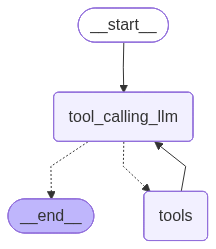

In [46]:
#ReAct Architecture

graph_builder = StateGraph(State)
graph_builder.add_node("tool_calling_llm",tool_calling_llm)
graph_builder.add_node("tools",ToolNode(tools))
graph_builder.add_conditional_edges("tool_calling_llm",tools_condition)
graph_builder.add_edge(START,"tool_calling_llm")
graph_builder.add_edge("tools","tool_calling_llm")
graph = graph_builder.compile()
graph

In [48]:
response = graph.invoke({"messages" : "What is Cricket game? and then give me multiplication of 2 and 10"})
response["messages"][-1].content

[{'type': 'text',
  'text': "Cricket is a bat-and-ball game played between two teams of eleven players. It is played on a field with a 22-yard (20-meter) pitch at the center, which has a wicket at each end. Each wicket is made of two bails balanced on three stumps. Two players from the batting team, the striker and non-striker, stand in front of the wickets with bats, while a bowler from the fielding team bowls the ball towards the striker's wicket. Players can be dismissed in various ways, including being bowled (when the ball hits the striker's wicket and dislodges the bails), or by the fielding team catching the ball after it's hit by the bat but before it touches the ground, or by hitting a wicket with the ball before a batter can cross the crease line in front of the wicket.\n\nThe multiplication of 2 and 10 is 20.",
  'extras': {'signature': 'CosHAQw51scCcPE0QB1VyTYv5FnnsTigIFNIuLh5MjimoG+yJcQE0KWGxO/za3u60T3zd6mfFz/W+PT5kdg/kW4kUePUjW+DRLvLUxfEYI54Cfy2X8kMblB5DrBcCMoOZpFz0TJDMau

In [49]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is Cricket game? and then give me multiplication of 2 and 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (db47015e-97e9-46c5-981f-6e396088750d)
 Call ID: db47015e-97e9-46c5-981f-6e396088750d
  Args:
    query: What is Cricket game?
================================= Tool Message =================================
Name: tavily_search

{"query": "What is Cricket game?", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://en.wikipedia.org/wiki/Cricket", "title": "Cricket - Wikipedia", "content": "# Cricket. **Cricket** is a bat-and-ball game that is played between two teams of eleven players on a field, at the centre of which is a 22-yard (20-metre; 66-foot) pitch with a wicket at each end, each comprising two bails \"Bail (cricket)\") (small sticks) balanced on three stumps \"Stump (cricket)\"). Two playe

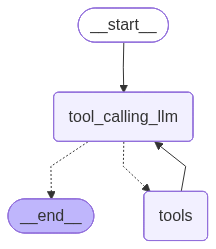

In [50]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
graph_builder = StateGraph(State)
graph_builder.add_node("tool_calling_llm",tool_calling_llm)
graph_builder.add_node("tools",ToolNode(tools))
graph_builder.add_conditional_edges("tool_calling_llm",tools_condition)
graph_builder.add_edge(START,"tool_calling_llm")
graph_builder.add_edge("tools","tool_calling_llm")
graph = graph_builder.compile(checkpointer=memory)
graph

In [51]:
config = {"configurable" : {"thread_id" : "1"}}
response = graph.invoke({"messages" : "What is my name ?"},config=config)
response["messages"][-1].content

'I do not know your name. I am a large language model, able to communicate in response to a wide range of prompts and questions, but I have no memory of past interactions.'

In [ ]:
response = graph.invoke({"messages" : "Hi, I'm Harman Singh"},config=config)
response["messages"][-1].content

"Hi Harman Singh, it's nice to meet you! How can I help you today?"

In [ ]:
response = graph.invoke({"messages" : "What is my name ?"},config=config)
response["messages"][-1].content

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite\nPlease retry in 45.527133325s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerM

In [52]:
##Streaming

for chunks in graph.stream({"messages" : "What is the difference b/w plastic and metal"},config=config):
    print(chunks)

{'tool_calling_llm': {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"query": "difference between plastic and metal properties"}'}, '__gemini_function_call_thought_signatures__': {'85bcf8a1-8492-4f77-82ef-ea0da10b332d': 'CugDAQw51sfpGgZYyRT7P4bt41O4sU7BBlOo2mR0bvMk6We45BWeLNxX1J79n8ElAMxDUPqtH6ByYrQTqAP+xAhYDCWyRHLfw7GKupGsJdocBEAQmCenHfqOD9N/+VaoLo08uLt5QEExkIz99QKhlhweLYfMmI3i4JN7/PDwHeWQCu/JjKf9F5tPab48vU4NsyAq4toZ1CBPUO3sLGSQBaEqcUHtPSl/pRjyp4L8U4Ds6Ze9V/An1r4L55v0ghLYVyt9ucI/0rBIeeuqw8S1UbiKOYdSEsH6SsOwqmEZF41DJMJhq3tzIdOQG/3aV2KZHoioALYgOPAatva1TNBwmV1gHJWQkt+jaayQWXJG9eQp1/OtjdLr94CB5NQQzNdSVSj9r9rkXpWb2Mjk99er7wc39ukOv8qNLK6O5F/2PDP5yYNgi4+N3e9WHO5Um+1BJTfTFOAwLfIRZoFt43OqwNIMw0htt4tir06xnOjuxn2JzWiGB2Cidh3wrYJkfLg85288KI3faFqb4ol+VA+AuOrFyLmFSi5uzLDxZxMDmSNwIGFvckoh4n47MwJf9orviM6OoZYs3fFDs6XgbfXDYikgnNW8mh9clGA1UdS0siIaCv2lmQcr2WCDn9I8EguLoDe9ps9qcyJ0k9E='}}, response_metadata={'finish_reason': 'STOP', 'model_na

##Human in the loop

In [102]:
from langgraph.types import interrupt,Command
from langchain.tools import tool
@tool
def human_assistance(query : str):
    """Returns after taking assistance from human"""
    assistance = interrupt({"query":query})
    return assistance["data"]

tool = TavilySearch(max_results=2)

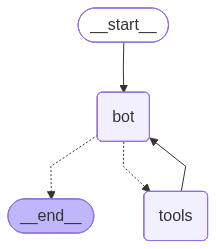

In [103]:
graph_builder = StateGraph(State)
tools = [tool,human_assistance]
def bot(state : State):
    message = llm_with_tools.invoke(state["messages"])
    return {"messages" : [message]}
graph_builder.add_node("bot",bot)
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools",tool_node)
graph_builder.add_edge(START,"bot")
graph_builder.add_edge("tools","bot")
graph_builder.add_conditional_edges("bot",tools_condition)
graph = graph_builder.compile(checkpointer=memory)
graph

In [104]:
query = "I need an expert guidance to tell the cricket winner, could you request tool ?"
event = graph.stream(
    {"messages" : query },
    config,
    stream_mode = "values"
)

In [105]:
for e in event:
    if "messages" in e:
        e["messages"][-1].pretty_print()

================================ Human Message =================================

I need an expert guidance to tell the cricket winner, could you request tool ?


KeyboardInterrupt: 

In [106]:
human_response = "Cricket's winner is cricket itself, no one is bigger than the game!"
interupt = Command(
    resume = {"data":human_response}
)
events = graph.stream(
    interupt,
    config,
    stream_mode="values"
)

In [107]:
for e in events:
    if "messages" in e:
        e["messages"][-1].pretty_print()

================================ Human Message =================================

I need an expert guidance to tell the cricket winner, could you request tool ?


ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 59.41680786s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTi